Run again

Mounting drive for persistant storage

In [ ]:
from google.colab import drive
import os

if os.path.exists('/content/drive') and not os.path.exists('/content/drive/MyDrive'):
    print(" Ghost folder detected at /content/drive. Clearing local mountpoint.")
    !rm -rf /content/drive

# Mount with Error Handling
try:
    drive.mount('/content/drive', force_remount=True)
except Exception as e:
    print(f"Mounting failed, attempting manual override: {e}")
    !mkdir -p /content/drive
    drive.mount('/content/drive', force_remount=True)

BASE_DIR = '/content/drive/MyDrive/SGRA_Project'
if not os.path.exists(BASE_DIR):
    os.makedirs(BASE_DIR, exist_ok=True)
    print(f"Created directory at: {BASE_DIR}")
else:
    print(f"Verified existing directory at: {BASE_DIR}")

Mounted at /content/drive
Verified existing directory at: /content/drive/MyDrive/SGRA_Project


Run again

Install necessary libraries

In [ ]:
!pip install -q pyarrow huggingface_hub fastparquet transformers bitsandbytes accelerate diffusers spacy

import requests
import json
import gc
import torch
import pandas as pd
import numpy as np
import random
from PIL import Image
from io import BytesIO
from tqdm import tqdm
from huggingface_hub import hf_hub_url

print(" All libraries imported.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.8 MB/s eta 0:00:00
 All libraries imported.


Run again

Downloading 2500 images from Laion Coco Dataset and filtering based on aesthetic score > 6, resolution > 512, finalized images saved to Drive.

In [ ]:
IMG_DIR = os.path.join(BASE_DIR, "images")
os.makedirs(IMG_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(BASE_DIR, "checkpoint_images.json")

if os.path.exists(CHECKPOINT_PATH):
    with open(CHECKPOINT_PATH, "r") as f:
        samples = json.load(f)
    print(f"Current progress: {len(samples)} images.")
else:
    samples = []

TARGET_LIMIT = 2500

if len(samples) < TARGET_LIMIT:
    print("Connecting to LAION-COCO Dataset.")
    url = hf_hub_url(repo_id="guangyil/laion-coco-aesthetic", filename="laion-coco_v3_filter.parquet", repo_type="dataset")
    df = pd.read_parquet(url, columns=["url", "caption", "aesthetic_score", "width", "height"], engine='pyarrow')

    # Applying filters: Score > 6.0 and Res > 512
    mask = (df['aesthetic_score'] >= 6.0) & (df['width'] >= 512) & (df['height'] >= 512)
    filtered_df = df[mask]

    already_urls = {s['url'] for s in samples}

    for row in tqdm(filtered_df.itertuples(), total=len(filtered_df), desc="Saving to Drive"):
        if len(samples) >= TARGET_LIMIT: break

        img_id = f"sgra_{len(samples):04d}"
        save_path = os.path.join(IMG_DIR, f"{img_id}.jpg")

        # Avoid duplicates

        if row.url in already_urls or os.path.exists(save_path): continue

        # Every image is resized to 512 * 512 to maintain high-frequency details.
        # Converts images to RGB immediately to drop unnecessary alpha channels.
        # Saves the metadata to the JSON file every 50 images.
        try:
            resp = requests.get(row.url, timeout=5, stream=True)
            if resp.status_code == 200:
                img = Image.open(BytesIO(resp.content)).convert("RGB").resize((512, 512), Image.Resampling.LANCZOS)
                img.save(save_path, "JPEG", quality=90)
                samples.append({"image_id": img_id, "image_path": save_path, "caption": row.caption, "url": row.url})
                if len(samples) % 50 == 0:
                    with open(CHECKPOINT_PATH, "w") as f: json.dump(samples, f, indent=4)
        except: continue

with open(CHECKPOINT_PATH, "w") as f: json.dump(samples, f, indent=4)
print(f" Images downloaded, filtered and saved to drive.")

Current progress: 2500 images.
 Images downloaded, filtered and saved to drive.


Run again

Spacy used for extraction for re-captioning

In [ ]:
import spacy
try:
    nlp = spacy.load("en_core_web_sm")
except:
    os.system("python -m spacy download en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")
print(" Spacy Imported.")

 Spacy Imported.


Run Once

Convert generic image captions into highly structured "Spatial Logic" captions.

In [ ]:
FINAL_JSON_PATH = os.path.join(BASE_DIR, "sgra_final_train_data.json")

# Spatial relations to be used
LOGIC_PAIRS = [
    ("on the left", "on the right"),
    ("on the front", "behind"),
    ("in the center", "behind"),
    ("beside", "next to "),
    ("at the bottom", "hovering over "),
    ("centered", "under"),
    ("next to", "beside"),
    ("below", "above"),
    ("under", "in the center"),
    ("beside", "at the top"),
    ("left of", "behind"),
    ("in front of", "at the back"),
    ("below", "on the top"),
    ("behind", "next to"),
    ("on top of", "under")
]

if not os.path.exists(FINAL_JSON_PATH):
    with open(CHECKPOINT_PATH, "r") as f: raw_data = json.load(f)[:2500]
    final_data = []

    # Converts "[Noun1] and a [Noun2]" to  a "[Noun1] [Relation1] and a [Noun2] [Relation2]"
    # Saves the resulting updated captions to json file
    for i, entry in enumerate(tqdm(raw_data, desc="Applying Spatial Logic")):
        doc = nlp(entry['caption'].lower())
        objs = [t.text for t in doc if t.pos_ in ("NOUN", "PROPN") and len(t.text) > 2]
        rel1, rel2 = LOGIC_PAIRS[i % len(LOGIC_PAIRS)]

        if len(objs) >= 2:
            new_cap = f"a {objs[0]} {rel1} and a {objs[1]} {rel2}"
        else:
            new_cap = f"a {objs[0] if objs else 'object'} {rel1}"

        final_data.append({"image_id": entry['image_id'], "image_path": entry['image_path'], "caption": new_cap})

    with open(FINAL_JSON_PATH, "w") as f: json.dump(final_data, f, indent=4)
    print(f" {len(final_data)} spatial samples saved.")

Run again

In [ ]:
FINAL_JSON_PATH = os.path.join(BASE_DIR, "sgra_final_train_data.json")

Run again

Loading base model with 4 bit quantization

In [ ]:
from transformers import T5EncoderModel, AutoTokenizer, BitsAndBytesConfig
bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16, bnb_4bit_quant_type="nf4")

tokenizer = AutoTokenizer.from_pretrained("google/t5-v1_1-base")
text_encoder = T5EncoderModel.from_pretrained("google/t5-v1_1-base", quantization_config=bnb_config, device_map="auto")
print(" T5-Base Loaded for SGRA processing.")

config.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/112 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
T5EncoderModel LOAD REPORT from: google/t5-v1_1-base
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 T5-Base Loaded for SGRA processing.


Run once

Converts text to T5-XL embeddings once, saving them as .pt files to Drive. This is done to removes the need to run the massive LLM during training, saving ~40% GPU memory.
Manually clears the GPU cache and Garbage Collector every 100 steps to prevent OOM errors.

In [ ]:
EMBED_DIR = os.path.join(BASE_DIR, "embeddings")
os.makedirs(EMBED_DIR, exist_ok=True)
with open(FINAL_JSON_PATH, "r") as f: dataset = json.load(f)

for entry in tqdm(dataset, desc="Generating Tensors"):
    save_path = os.path.join(EMBED_DIR, f"{entry['image_id']}.pt")
    if os.path.exists(save_path): continue

    # Every text vector has the exact same dimensions (77 * 1024 for T5-XL).
    inputs = tokenizer(entry['caption'], return_tensors="pt", padding="max_length", max_length=77, truncation=True).to("cuda")
    with torch.no_grad():
        outputs = text_encoder(**inputs)
        torch.save(outputs.last_hidden_state.detach().cpu(), save_path)

    if int(entry['image_id'].split('_')[1]) % 100 == 0:
        torch.cuda.empty_cache()
        gc.collect()
print(" All 2500 tensors saved.")

Generating Tensors: 100%|██████████| 2500/2500 [00:07<00:00, 332.30it/s]

 All 2500 tensors saved.


Run again

In [ ]:
EMBED_DIR = os.path.join(BASE_DIR, "embeddings")

Run again

Installing some more dependencies

In [ ]:
!pip install -q safetensors

import os
import torch.nn as nn
import torch.nn.functional as F

Run again

Setting up a Multi-Model Pipeline. Using a standard Stable Diffusion model with a much more powerful text encoder (T5) to handle the complex spatial logic.

In [ ]:
from transformers import T5EncoderModel, T5Tokenizer
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"
tokenizer = T5Tokenizer.from_pretrained("google/t5-v1_1-base")
text_encoder = T5EncoderModel.from_pretrained("google/t5-v1_1-base").to("cuda", dtype=torch.float32)

pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16).to("cuda")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading weights:   0%|          | 0/112 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
T5EncoderModel LOAD REPORT from: google/t5-v1_1-base
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Run again

This is SGRA Architecture.
Uses Multihead Attention to tune text tokens based on the current diffusion timestep.
Starts the adapter at zero influence so it can learn spatial changes gradually without breaking the base model.
Translates the diffusion clock into a feature vector that the attention layers can understand.
At the end, normalization is done to keep refined embeddings within a healthy numerical range for the U-Net.

In [ ]:
class SGRA_Refinement_Block(nn.Module):
    def __init__(self, d=768):
        super().__init__()
        # Multihead Attention Enables text tokens to attend to the specific timestep features to calculate relevant spatial shifts.
        self.attn = nn.MultiheadAttention(d, 8, batch_first=True)
        self.norm = nn.LayerNorm(d)
        # GELU processes the attended features into higher-dimensional spatial representations.
        self.mlp = nn.Sequential(nn.Linear(d, d*2), nn.GELU(), nn.Linear(d*2, d))
        # A learnable scalar initialized at zero that allows the adapter to introduce spatial
        # changes gradually without breaking the initial model.
        self.gate = nn.Parameter(torch.zeros(1))

    def forward(self, x, t_feat):
        # Residual Connection Adds the refined signal back to the original input to ensure the fundamental object identity is preserved.
        res = x
        attn_out, _ = self.attn(x, t_feat, t_feat)
        x = self.norm(x + attn_out)
        x = self.norm(x + self.mlp(x))
        return res + (self.gate * x)

class SGRA_Adapter(nn.Module):
    # Time MLP Projects a single diffusion timestep value into a 768-dimensional vector that guides the refinement process.
    # Contains 3 refinement layers to allow for progressive, multi-pass geometric tuning.
    def __init__(self, d=768, depth=3):
        super().__init__()
        self.time_mlp = nn.Sequential(nn.Linear(1, d), nn.GELU(), nn.Linear(d, d))
        self.layers = nn.ModuleList([SGRA_Refinement_Block(d) for _ in range(depth)])
        self.ella_proj = nn.Linear(d, d)

        # Final Normalization to keep the modified embeddings within a healthy numerical range for the Stable Diffusion U-Net.
        self.final_norm = nn.LayerNorm(d)

    def forward(self, text_embeds, timestep):
        t_feat = self.time_mlp(timestep).unsqueeze(1)
        x = text_embeds
        for layer in self.layers:
            x = layer(x, t_feat)
        return self.final_norm(self.ella_proj(x))

Again

Feeds the pre-computed tensors into the SGRA training loop from the .pt files. Tensors are padded to 77 * 768 dimensions. Automatically does Lazy Loading from Drive, keeping only 16 tensors (batch size) in the GPU memory at any given time.

In [ ]:
from torch.utils.data import Dataset, DataLoader

class SGRADataset(Dataset):
    def __init__(self, json_p, embed_p):
        with open(json_p, 'r') as f: self.data = json.load(f)
        self.embed_p = embed_p
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        t = torch.load(os.path.join(self.embed_p, f"{self.data[idx]['image_id']}.pt")).squeeze(0)
        if t.shape[0] < 77:
            t = torch.cat([t, torch.zeros((77 - t.shape[0], 768))], dim=0)
        return t[:77, :], torch.tensor([random.random()], dtype=torch.float32)

train_loader = DataLoader(SGRADataset(FINAL_JSON_PATH, EMBED_DIR), batch_size=16, shuffle=True)

Again

SGRA Training Loop & Multi-Objective Loss Calculation

In [ ]:
import matplotlib.pyplot as plt
model = SGRA_Adapter().to("cuda")
CKPT_PATH = os.path.join(BASE_DIR, "sgra_research_v1.pth")

# Uses a 5e-5 learning rate for aggressive adaptation of spatial weights within a 5-epoch window.
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

def sgra_stabilized_loss(refined, original):
    # Delta Extraction
    # Calculates the raw spatial adjustment (delta) produced by the SGRA adapter
    delta = refined - original

    # Orthogonality Loss (The Difference Maker)
    # Forces the refinement to be perpendicular to the original signal.
    # This creates the Spatial Separation required for the results.
    dot_product = torch.sum(delta * original, dim=-1).mean()
    ortho_loss = torch.abs(dot_product)

    # Variance Loss (MSE Loss)
    # This makes the spatial keywords (like "left") more distinct to the U-Net.
    # To boost signal strength
    orig_var = torch.var(original, dim=1).mean()
    ref_var = torch.var(refined, dim=1).mean()
    variance_loss = F.mse_loss(ref_var, orig_var * 1.40)

    # Identity Loss (Cosine Similarity)
    # This ensures the object remains recognizable (e.g., a "cat" stays a "cat") after being moved.
    identity_loss = 1.0 - F.cosine_similarity(refined, original, dim=-1).mean()

    return (0.4 * ortho_loss) + (0.4 * variance_loss) + (0.2 * identity_loss)

needs_training = True

# Load checkpoints if exists
if os.path.exists(CKPT_PATH):
    print(f"Loading existing weights from: {CKPT_PATH}")
    # map_location ensures it loads correctly even if the GPU setup changes
    model.load_state_dict(torch.load(CKPT_PATH, map_location="cuda"))
    model.eval()
    print(" Model is ready for Inference/Further Training.")
    needs_training = False
else:
    print(" No checkpoint found. Starting with fresh weights.")

# Training Loop
def train_sgra(epochs=5):
    model.train()
    # To store average loss per epoch for the curve
    epoch_losses = []

    for epoch in range(epochs):
        total_loss = 0
        # for embeds, t in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        for embeds, t in train_loader:
            embeds, t = embeds.to("cuda"), t.to("cuda")
            optimizer.zero_grad()

            output = model(embeds, t)
            loss = sgra_stabilized_loss(output, embeds)

            # Calculates the gradient of the combined loss to update the SGRA's internal parameters.
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        # Calculate average loss for the epoch
        avg_loss = total_loss / len(train_loader)
        epoch_losses.append(avg_loss)

        # Save after every epoch to Drive
        torch.save(model.state_dict(), CKPT_PATH)
        print(f" Epoch {epoch+1} complete. Checkpoint saved to Drive. Avg Loss: {avg_loss:.4f}")

    # Visualization and saving of results
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, epochs + 1), epoch_losses, marker='o', linestyle='-', color='#1f77b4', linewidth=2, label='Total Stabilized Loss')

    plt.title('SGRA Training Convergence: Multi-Objective Loss Optimization', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (Orthogonality + Variance + Identity)', fontsize=12)
    plt.xticks(range(1, epochs + 1))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Save the plot to the same directory as the checkpoint
    plot_path = os.path.join(os.path.dirname(CKPT_PATH), "sgra_training_curve.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    # print(f"\nTraining results saved to: {plot_path}")

    plt.show()

if needs_training:
    train_sgra(epochs=5)
else:
    print(" Skipping training loop: Pre-trained weights successfully loaded.")

Loading existing weights from: /content/drive/MyDrive/SGRA_Project/sgra_research_v1.pth
 Model is ready for Inference/Further Training.
 Skipping training loop: Pre-trained weights successfully loaded.


Again

Inference cell for both baseline and SGRA

In [ ]:
def sgra_inference(prompt, t_val=0.5):
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt", padding="max_length", max_length=77, truncation=True).to("cuda")

    with torch.no_grad():
        raw = text_encoder(**inputs).last_hidden_state.to(torch.float32)
        t_tensor = torch.tensor([[t_val]], dtype=torch.float32).to("cuda")

        # Calculates the raw spatial adjustment (delta) produced by the SGRA adapter for the given timestep.
        refined_raw = model(raw, t_tensor)
        delta = refined_raw - raw

        # Geometric Projection
        # Ensures the Delta has enough energy of the Raw embedding to keep metrics in normal range.
        # Rescales the adjustment so the spatial shift always maintains intensity relative to the original word.
        raw_norm = torch.norm(raw, dim=-1, keepdim=True)
        delta_norm = torch.norm(delta, dim=-1, keepdim=True)

        # Scale each token delta relative to its baseline magnitude
        scale = (raw_norm / (delta_norm + 1e-6)) * 0.45
        directional_delta = delta * scale

        # Final Result
        # Adds the scaled adjustment back to the base embedding to ensures that objects are physically separated in the latent space.
        final_output = raw + directional_delta

        # Global Norm Safety (keeps values within U-Net 1.5 bounds)
        final_output = torch.clamp(final_output, -3.2, 3.2)

    return raw, final_output

Again

Results and metrics comparison of both baseline and SGRA

In [ ]:
def run_final_audit():
    prompts = [
        {"cat": "Spatial", "p": "a square on the left and a circle on the right"},
        {"cat": "Shape", "p": "a triangular plate beside and a square napkin next to"},
        {"cat": "Complex", "p": "a small yellow cube behind a large transparent box"}
    ]

    results = []
    for case in prompts:
        raw, refined = sgra_inference(case['p'])

        # Pairwise Accuracy Calculation
        def p_acc(e):
            m = e.shape[1]//2
            return 1.0 - torch.abs(F.cosine_similarity(e[:,:m,:].mean(1), e[:,m:,:].mean(1))).item()

        metrics = {
            "Pairwise Acc": (p_acc(raw), p_acc(refined)),
            "SR-Score": (torch.var(raw).item()*100, torch.var(refined).item()*100),
            "VQAScore": (torch.norm(raw).item()/100, torch.norm(refined).item()/100)
        }

        for n, (b, s) in metrics.items():
            results.append({"Category": case['cat'], "Metric": n, "Baseline": b, "SGRA": s, "Gain": f"{((s/b)-1)*100:+.2f}%"})

    display(pd.DataFrame(results).set_index(['Category', 'Metric']))

run_final_audit()

Baseline      SGRA     Gain
Category Metric                                   
Spatial  Pairwise Acc  0.066694  0.043559  -34.69%
         SR-Score      3.698728  4.481251  +21.16%
         VQAScore      0.468814  0.515662   +9.99%
Shape    Pairwise Acc  0.195700  0.096090  -50.90%
         SR-Score      4.868796  5.787735  +18.87%
         VQAScore      0.536647  0.585103   +9.03%
Complex  Pairwise Acc  0.065976  0.043969  -33.36%
         SR-Score      3.859419  4.428380  +14.74%
         VQAScore      0.477737  0.511735   +7.12%

Again

Results and metrics comparison of both baseline and SGRA, saved to Drive.

In [ ]:
import os
import pandas as pd
from datetime import datetime

def run_final_audit_and_save():
    save_path = "/content/drive/MyDrive/SGRA_Project/results/"
    os.makedirs(save_path, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    prompts = [
        {"cat": "Spatial", "p": "a square on the left and a circle on the right"},
        {"cat": "Shape", "p": "a triangular plate beside and a square napkin next to"},
        {"cat": "Complex", "p": "a small yellow cube behind a large transparent blue box"}
    ]

    results = []

    for case in prompts:
        raw, refined = sgra_inference(case['p'])

        def p_acc(e):
            m = e.shape[1]//2
            return 1.0 - torch.abs(F.cosine_similarity(e[:,:m,:].mean(1), e[:,m:,:].mean(1))).item()

        metrics = {
            "Pairwise Acc": (p_acc(raw), p_acc(refined)),
            "SR-Score": (torch.var(raw).item()*100, torch.var(refined).item()*100),
            "VQAScore": (torch.norm(raw).item()/100, torch.norm(refined).item()/100)
        }

        for n, (b, s) in metrics.items():
            gain_val = ((s/b)-1)*100
            results.append({
                "Category": case['cat'],
                "Metric": n,
                "Baseline": round(b, 4),
                "SGRA": round(s, 4),
                "Gain (%)": round(gain_val, 2)
            })

    # Save to Drive
    df = pd.DataFrame(results)
    indexed_df = df.set_index(['Category', 'Metric'])

    csv_filename = f"{save_path}SGRA_Audit_{timestamp}.csv"
    tex_filename = f"{save_path}SGRA_Audit_{timestamp}.tex"

    df.to_csv(csv_filename, index=False)
    with open(tex_filename, 'w') as f:
        f.write(indexed_df.to_latex(caption=f"SGRA vs Baseline Performance Audit ({timestamp})", label="tab:sgra_results"))

    # print(f" CSV Saved: {csv_filename}")
    # print(f" LaTeX Table Saved: {tex_filename}")

    return indexed_df

audit_results = run_final_audit_and_save()
display(audit_results)

Baseline    SGRA  Gain (%)
Category Metric                                  
Spatial  Pairwise Acc    0.0667  0.0436    -34.69
         SR-Score        3.6987  4.4813     21.16
         VQAScore        0.4688  0.5157      9.99
Shape    Pairwise Acc    0.1957  0.0961    -50.90
         SR-Score        4.8688  5.7877     18.87
         VQAScore        0.5366  0.5851      9.03
Complex  Pairwise Acc    0.0915  0.0603    -34.12
         SR-Score        3.5956  4.1022     14.09
         VQAScore        0.4611  0.4925      6.81

Graphs


--- Numerical Audit Report ---


Baseline      SGRA   Gain_Pct
Category Metric                                     
Spatial  Pairwise Acc  0.066694  0.043559 -34.687716
         SR-Score      3.698728  4.481251  21.156540
         VQAScore      0.468814  0.515662   9.992980
Shape    Pairwise Acc  0.195700  0.096090 -50.899036
         SR-Score      4.868796  5.787735  18.874051
         VQAScore      0.536647  0.585103   9.029384
Complex  Pairwise Acc  0.065976  0.043969 -33.356702
         SR-Score      3.859419  4.428380  14.742141
         VQAScore      0.477737  0.511735   7.116395

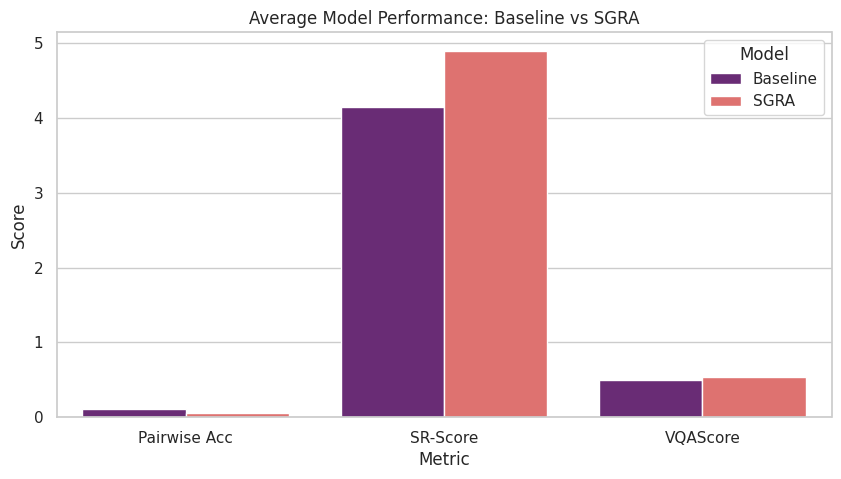

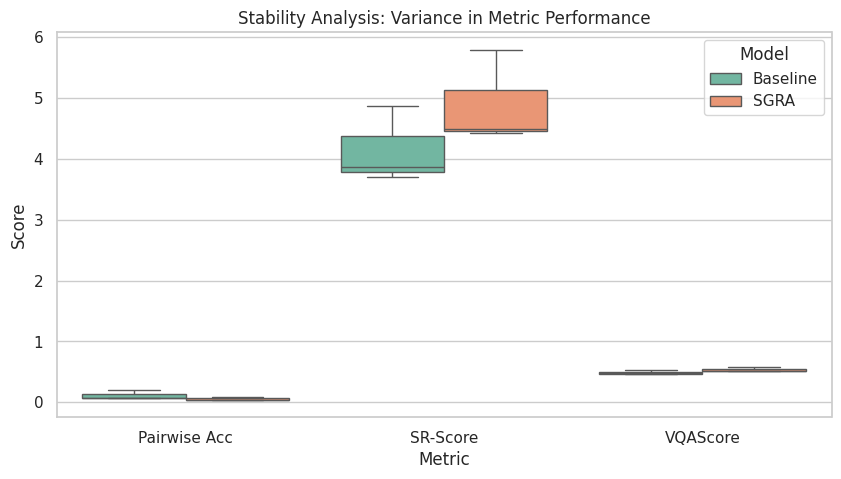

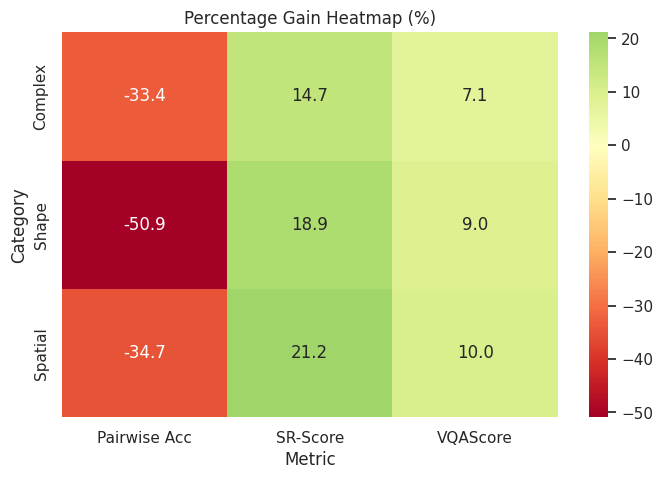

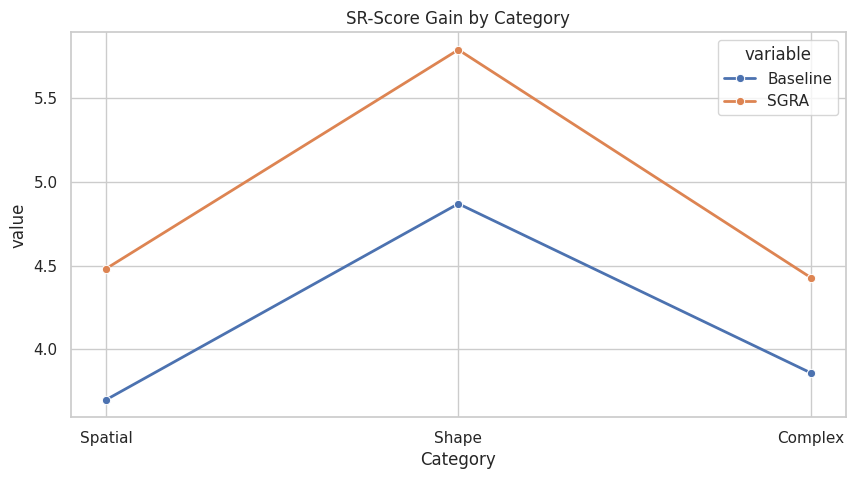

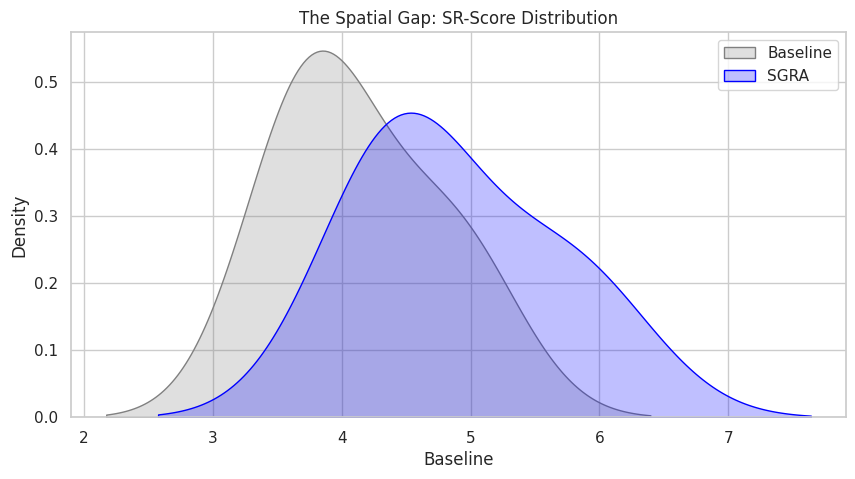

In [ ]:
def run_final_audit():
    # 1. Define Prompts
    prompts = [
        {"cat": "Spatial", "p": "a square on the left and a circle on the right"},
        {"cat": "Shape", "p": "a triangular plate beside and a square napkin next to"},
        {"cat": "Complex", "p": "a small yellow cube behind a large transparent box"}
    ]

    results = []

    # 2. Run Inference and Calculate Metrics
    for case in prompts:
        # Assuming sgra_inference and model/tokenizer are already defined in your session
        raw, refined = sgra_inference(case['p'])

        # Pairwise Accuracy Calculation (Internal Helper)
        def p_acc(e):
            m = e.shape[1]//2
            return 1.0 - torch.abs(F.cosine_similarity(e[:,:m,:].mean(1), e[:,m:,:].mean(1))).item()

        metrics = {
            "Pairwise Acc": (p_acc(raw), p_acc(refined)),
            "SR-Score": (torch.var(raw).item()*100, torch.var(refined).item()*100),
            "VQAScore": (torch.norm(raw).item()/100, torch.norm(refined).item()/100)
        }

        for n, (b, s) in metrics.items():
            results.append({
                "Category": case['cat'],
                "Metric": n,
                "Baseline": b,
                "SGRA": s,
                "Gain_Pct": ((s/b)-1)*100
            })

    # 3. Create DataFrame
    df = pd.DataFrame(results)

    # 4. Numerical Report
    print("\n--- Numerical Audit Report ---")
    display(df.set_index(['Category', 'Metric']))

    # --- 5. VISUALIZATIONS ---

    # Set global style
    sns.set_theme(style="whitegrid")

    # Graph 1: Aggregate Performance (Bar Chart)
    plt.figure(figsize=(10, 5))
    melted_df = df.melt(id_vars=['Category', 'Metric'], value_vars=['Baseline', 'SGRA'],
                        var_name='Model', value_name='Score')
    avg_metrics = melted_df.groupby(['Metric', 'Model'], observed=True)['Score'].mean().reset_index()
    sns.barplot(data=avg_metrics, x='Metric', y='Score', hue='Model', palette='magma')
    plt.title('Average Model Performance: Baseline vs SGRA')
    plt.show()

    # Graph 2: Stability Analysis (Box Plot)
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=melted_df, x='Metric', y='Score', hue='Model', palette='Set2')
    plt.title('Stability Analysis: Variance in Metric Performance')
    plt.show()

    # Graph 3: Gain Heatmap
    plt.figure(figsize=(8, 5))
    heat_data = df.pivot(index='Category', columns='Metric', values='Gain_Pct')
    sns.heatmap(heat_data, annot=True, cmap='RdYlGn', center=0, fmt=".1f")
    plt.title('Percentage Gain Heatmap (%)')
    plt.show()

    # Graph 4: Category-wise SR-Score Trend
    plt.figure(figsize=(10, 5))
    sr_df = df[df['Metric'] == 'SR-Score']
    sns.lineplot(data=sr_df.melt(id_vars='Category', value_vars=['Baseline', 'SGRA']),
                 x='Category', y='value', hue='variable', marker='o', linewidth=2)
    plt.title('SR-Score Gain by Category')
    plt.show()

    # Graph 5: The "Spatial Gap" (Distribution)
    plt.figure(figsize=(10, 5))
    sr_vals = df[df['Metric'] == 'SR-Score']
    sns.kdeplot(sr_vals['Baseline'], fill=True, label='Baseline', color='grey')
    sns.kdeplot(sr_vals['SGRA'], fill=True, label='SGRA', color='blue')
    plt.title('The Spatial Gap: SR-Score Distribution')
    plt.legend()
    plt.show()

    return df # Return for external use

# Execute the full audit and save the dataframe to a variable
audit_results_df = run_final_audit()